In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("train.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.drop('Item_Identifier', axis=1, inplace=True)
df.drop('Outlet_Identifier', axis=1, inplace=True)

In [ ]:
df.isnull().sum()

Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [ ]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})

In [ ]:
df['Item_Visibility'] = df['Item_Visibility'].replace(0, df['Item_Visibility'].mean())

In [ ]:
df['Store_Age'] = 2026 - df['Outlet_Establishment_Year']
df.drop('Outlet_Establishment_Year', axis=1, inplace=True)

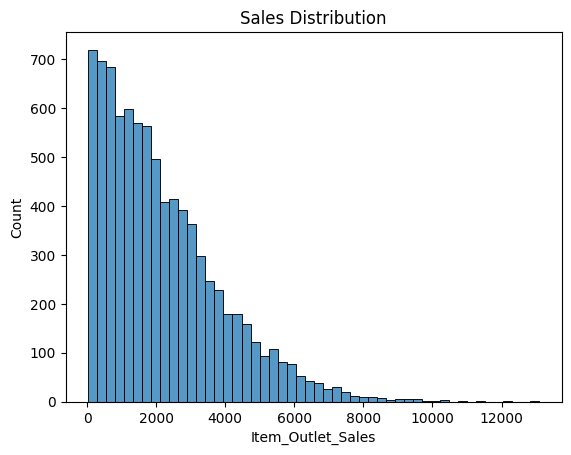

In [ ]:
sns.histplot(df['Item_Outlet_Sales'], bins=50)

plt.title("Sales Distribution")

plt.show()

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Store_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0.016047,249.8092,3735.1380,27,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
1,5.920,0.019278,48.2692,443.4228,17,True,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.500,0.016760,141.6180,2097.2700,27,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.200,0.066132,182.0950,732.3800,28,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.930,0.066132,53.8614,994.7052,39,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0.056783,214.5218,2778.3834,39,False,False,False,False,False,...,True,False,False,False,False,False,True,True,False,False
8519,8.380,0.046982,108.1570,549.2850,24,True,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False
8520,10.600,0.035186,85.1224,1193.1136,22,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
8521,7.210,0.145221,103.1332,1845.5976,17,True,False,False,False,False,...,True,False,False,True,False,False,True,False,True,False


In [ ]:
X = df.drop("Item_Outlet_Sales", axis=1)

y = df["Item_Outlet_Sales"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

"Linear Regression": LinearRegression(),

"Decision Tree": DecisionTreeRegressor(),

"Random Forest": RandomForestRegressor(),

"Gradient Boosting": GradientBoostingRegressor(),

"SVM": SVR(),

"KNN": KNeighborsRegressor()

}

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, pred)

    results[name] = r2

    print(name, "R2 Score:", r2)

Linear Regression R2 Score: 0.5798560399750234
Decision Tree R2 Score: 0.1654543627667454
Random Forest R2 Score: 0.5491879305328959
Gradient Boosting R2 Score: 0.6037971637548369
SVM R2 Score: 0.014793280225017469
KNN R2 Score: 0.483139809715908


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X,y)

# importances = model.feature_importances_

y_pred = model.predict(X_test)
print("R2:",r2_score(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred))
print("Feature Importances:", model.feature_importances_)



R2: 0.938368919418455
RMSE: 167511.43219388256


In [ ]:
# 